# 04 - Clustering Analysis

This notebook applies clustering algorithms to Old School RuneScape player profiles.

The objective is to identify hidden player groups based on their skill progression and aggregated profile metrics.

Since no predefined labels exist, clustering is an appropriate unsupervised learning method.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 2. Load the cleaned dataset

The cleaned dataset created in the previous notebook is loaded.

This dataset already contains:

- selected skill level features,
- engineered profile metrics,
- cleaned numeric values.

In [3]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
IMAGES_DIR = PROJECT_ROOT / "images"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

input_path = PROCESSED_DATA_DIR / "osrs_hiscores_cleaned.csv"

input_path

WindowsPath('C:/Projects/osrs-player-segmentation/data/processed/osrs_hiscores_cleaned.csv')

In [4]:
df = pd.read_csv(input_path)

df.head()

,player,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
0,Zezima,1466,76,76,75,1,1,1,1,80,...,45,1,33.000000,52.8,56.250,59.75,49.333333,99,1,31.568651
1,eszcape,2107,99,99,99,99,99,82,99,99,...,83,60,96.571429,76.8,86.375,89.00,87.791667,99,60,10.640281
2,Lynx Titan,2278,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.000,99.00,94.916667,99,1,20.004166
3,Hey Jase,2278,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.000,99.00,94.916667,99,1,20.004166
4,Woox,2340,99,99,99,99,99,99,99,99,...,99,63,99.000000,91.8,99.000,99.00,97.500000,99,63,7.348469


In [5]:
df.shape

(10, 34)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player               10 non-null     object 
 1   overall              10 non-null     int64  
 2   attack               10 non-null     int64  
 3   defence              10 non-null     int64  
 4   strength             10 non-null     int64  
 5   hitpoints            10 non-null     int64  
 6   ranged               10 non-null     int64  
 7   prayer               10 non-null     int64  
 8   magic                10 non-null     int64  
 9   cooking              10 non-null     int64  
 10  woodcutting          10 non-null     int64  
 11  fletching            10 non-null     int64  
 12  fishing              10 non-null     int64  
 13  firemaking           10 non-null     int64  
 14  crafting             10 non-null     int64  
 15  smithing             10 non-null     int64 

## 3. Create the feature matrix

Clustering algorithms require a numeric matrix.

In this matrix:

- each row = one OSRS player
- each column = one numeric feature

The `player` column is only an identifier and is excluded from model training.

In [7]:
feature_columns = [column for column in df.columns if column != "player"]

X = df[feature_columns].copy()

X.head()

,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,woodcutting,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
0,1466,76,76,75,1,1,1,1,80,78,...,45,1,33.000000,52.8,56.250,59.75,49.333333,99,1,31.568651
1,2107,99,99,99,99,99,82,99,99,81,...,83,60,96.571429,76.8,86.375,89.00,87.791667,99,60,10.640281
2,2278,99,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.000,99.00,94.916667,99,1,20.004166
3,2278,99,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.000,99.00,94.916667,99,1,20.004166
4,2340,99,99,99,99,99,99,99,99,99,...,99,63,99.000000,91.8,99.000,99.00,97.500000,99,63,7.348469


In [8]:
player_names = df["player"].values

player_names[:10]

array(['Zezima', 'eszcape', 'Lynx Titan', 'Hey Jase', 'Woox', 'B0aty',
       'Alkan', 'Settled', 'A Cold One', 'SoloMission'], dtype=object)

## 4. Standardize the data

Distance-based clustering methods are sensitive to scale differences.

For example:

- total level
- average skill
- standard deviation

may have different numeric ranges.

Therefore StandardScaler is applied.

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-2.87441552, -3.        , -3.        , -3.        , -3.        ,
        -3.        , -2.95469752, -3.        , -3.        , -2.18424475,
        -2.57989397, -2.17565873,  0.33333333, -2.99938036, -2.80750709,
        -2.65495395, -2.90265529, -2.33486893, -2.75577669, -3.        ,
        -3.        , -2.7470113 , -2.85379824, -2.86991128, -1.11307812,
        -2.99797964, -2.34200634, -2.87153645, -2.90364464, -2.92780746,
         0.        , -1.11819134,  1.93997088],
       [-0.42525913,  0.33333333,  0.33333333,  0.33333333,  0.33333333,
         0.33333333, -0.18787094,  0.33333333,  0.33333333, -1.80104391,
        -1.23492555, -1.81102319, -3.        ,  0.27267094, -0.73881766,
        -1.09321633, -0.43080772, -1.53662314, -0.87208123,  0.33333333,
         0.33333333, -0.86469092, -0.58790693, -0.54955748,  0.31767589,
         0.22370821, -0.56439242, -0.54300252, -0.41844769, -0.24182566,
         0.        ,  0.33817266, -0.15873846],
       [ 0.22810396,  0.3333

## 5. PCA visualization before clustering

The dataset contains many dimensions.

Principal Component Analysis (PCA) reduces the feature space to two components while preserving as much variance as possible.

This helps visualize player profiles before clustering.

In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "player": df["player"],
    "pca_1": X_pca[:, 0],
    "pca_2": X_pca[:, 1]
})

df_pca.head()

,player,pca_1,pca_2
0,Zezima,-15.111841,-0.586322
1,eszcape,-1.847042,3.625659
2,Lynx Titan,1.639530,-1.945135
3,Hey Jase,1.639530,-1.945135
4,Woox,2.279466,-0.013508


In [11]:
explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")

PC1 explained variance: 84.09%
PC2 explained variance: 9.06%
Total explained variance: 93.14%


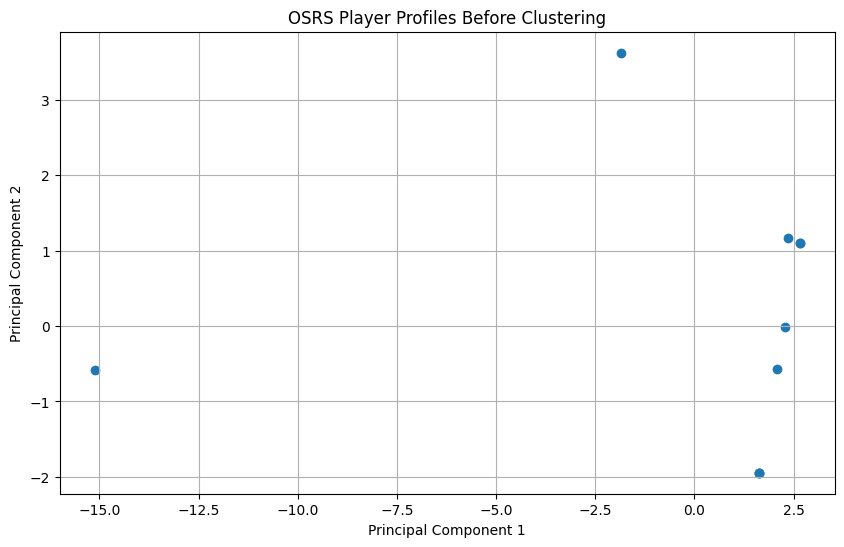

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(df_pca["pca_1"], df_pca["pca_2"])

plt.title("OSRS Player Profiles Before Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

## 6. Determine the optimal number of clusters

The KMeans algorithm requires the number of clusters (`k`) in advance.

Two common evaluation approaches are used:

- Elbow Method
- Silhouette Score

### 6.1 Elbow Method

The inertia value measures within-cluster compactness.

Lower values are better, but diminishing returns indicate a suitable cluster number.

In [13]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

inertias

C:\Users\EVGA\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\EVGA\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\EVGA\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


[320.00000000000017,
 64.92935455091086,
 26.840228045512337,
 4.776430341038327,
 0.6696202957757843,
 0.30113954333135406,
 2.8888949165808538e-31,
 5.662234036498473e-31,
 2.2648936145993894e-30,
 149.73096312149187]

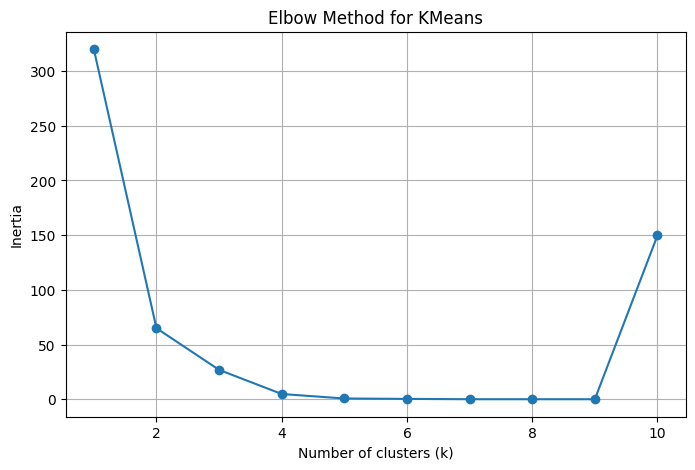

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.title("Elbow Method for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)

plt.show()

### 6.2 Silhouette Score

The silhouette score evaluates how well each player fits into its assigned cluster compared to neighboring clusters.

Higher values indicate better cluster separation.

In [15]:
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_scores

C:\Users\EVGA\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\EVGA\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\EVGA\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


[0.7198067680050697,
 0.5262032070645246,
 0.5125107127181497,
 0.6316111235929608,
 0.6088454532278248,
 0.5,
 0.5,
 0.5,
 0.5]

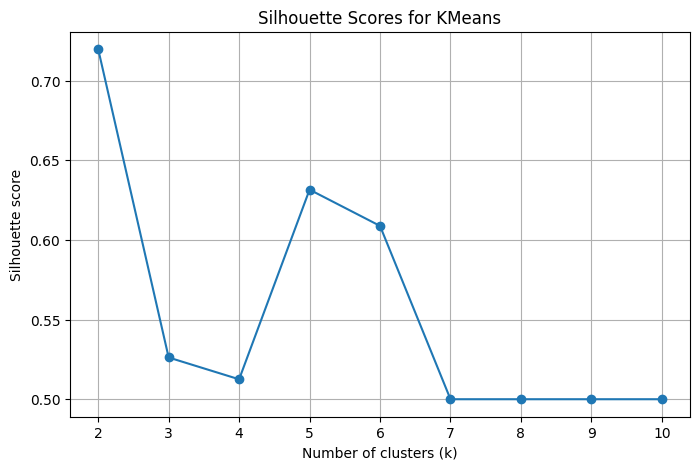

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Scores for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True)

plt.show()

## 7. Final KMeans clustering

Based on the evaluation metrics, a final cluster number is selected.

This value may be adjusted later depending on interpretability.

In [33]:
selected_k = 5

In [34]:
kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered["kmeans_cluster"] = kmeans_labels

df_clustered.head()

,player,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,...,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std,kmeans_cluster
0,Zezima,1466,76,76,75,1,1,1,1,80,...,1,33.000000,52.8,56.250,59.75,49.333333,99,1,31.568651,1
1,eszcape,2107,99,99,99,99,99,82,99,99,...,60,96.571429,76.8,86.375,89.00,87.791667,99,60,10.640281,2
2,Lynx Titan,2278,99,99,99,99,99,99,99,99,...,1,99.000000,79.4,99.000,99.00,94.916667,99,1,20.004166,0
3,Hey Jase,2278,99,99,99,99,99,99,99,99,...,1,99.000000,79.4,99.000,99.00,94.916667,99,1,20.004166,0
4,Woox,2340,99,99,99,99,99,99,99,99,...,63,99.000000,91.8,99.000,99.00,97.500000,99,63,7.348469,4


In [35]:
df_clustered["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0    3
1    1
2    1
3    3
4    2
Name: count, dtype: int64

## 8. Visualize KMeans clusters in PCA space

Each point represents one player.

Color indicates the assigned cluster.

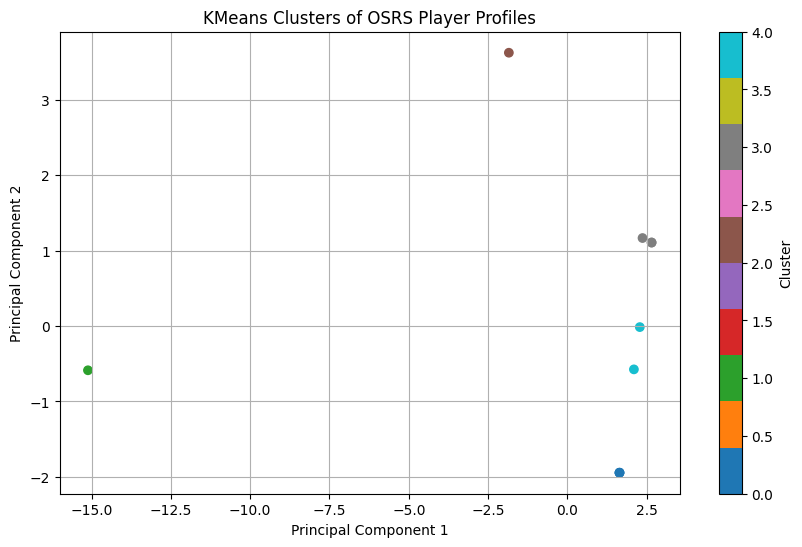

In [36]:
df_pca["kmeans_cluster"] = kmeans_labels

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_pca["pca_1"],
    df_pca["pca_2"],
    c=df_pca["kmeans_cluster"],
    cmap="tab10"
)

plt.title("KMeans Clusters of OSRS Player Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")

plt.show()

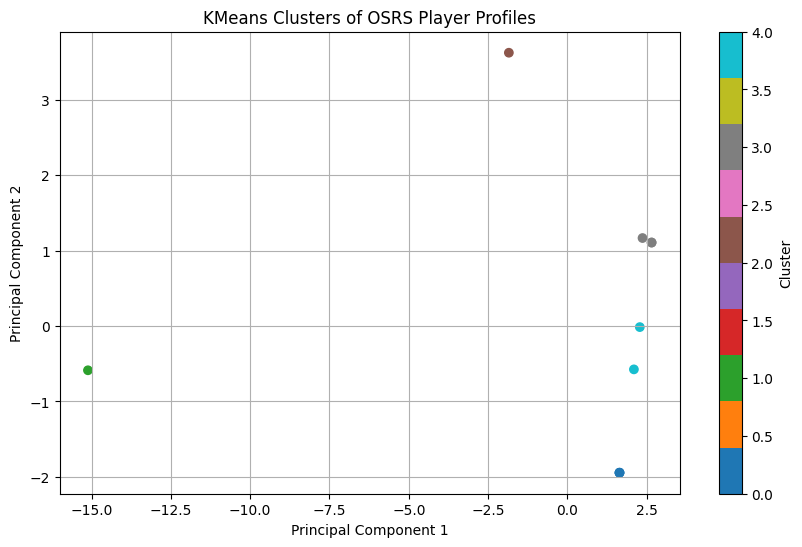

WindowsPath('C:/Projects/osrs-player-segmentation/images/kmeans_clusters_pca.png')

In [37]:
kmeans_plot_path = IMAGES_DIR / "kmeans_clusters_pca.png"

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_pca["pca_1"],
    df_pca["pca_2"],
    c=df_pca["kmeans_cluster"],
    cmap="tab10"
)

plt.title("KMeans Clusters of OSRS Player Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")

plt.savefig(kmeans_plot_path, dpi=300, bbox_inches="tight")
plt.show()

kmeans_plot_path

## 9. Cluster profile interpretation

To understand the discovered player groups, average feature values are calculated per cluster.

In [38]:
cluster_profile = df_clustered.groupby("kmeans_cluster")[feature_columns].mean()

cluster_profile

,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,woodcutting,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,2278.000000,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,...,99.0,1.0,99.000000,79.4,99.000000,99.00,94.916667,99.0,1.0,20.004166
1,1466.000000,76.0,76.0,75.0,1.0,1.0,1.0,1.0,80.0,78.0,...,45.0,1.0,33.000000,52.8,56.250000,59.75,49.333333,99.0,1.0,31.568651
2,2107.000000,99.0,99.0,99.0,99.0,99.0,82.0,99.0,99.0,81.0,...,83.0,60.0,96.571429,76.8,86.375000,89.00,87.791667,99.0,60.0,10.640281
3,2371.333333,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,...,99.0,99.0,99.000000,98.8,98.791667,98.50,98.805556,99.0,97.0,0.546545
4,2331.000000,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,...,99.0,54.0,99.000000,90.0,99.000000,99.00,97.125000,99.0,54.0,9.185587


In [39]:
profile_columns = [
    "overall",
    "combat_score",
    "gathering_score",
    "production_score",
    "support_score",
    "average_skill_level",
    "skill_level_std"
]

cluster_profile[profile_columns]

,overall,combat_score,gathering_score,production_score,support_score,average_skill_level,skill_level_std
kmeans_cluster,,,,,,,
0,2278.000000,99.000000,79.4,99.000000,99.00,94.916667,20.004166
1,1466.000000,33.000000,52.8,56.250000,59.75,49.333333,31.568651
2,2107.000000,96.571429,76.8,86.375000,89.00,87.791667,10.640281
3,2371.333333,99.000000,98.8,98.791667,98.50,98.805556,0.546545
4,2331.000000,99.000000,90.0,99.000000,99.00,97.125000,9.185587


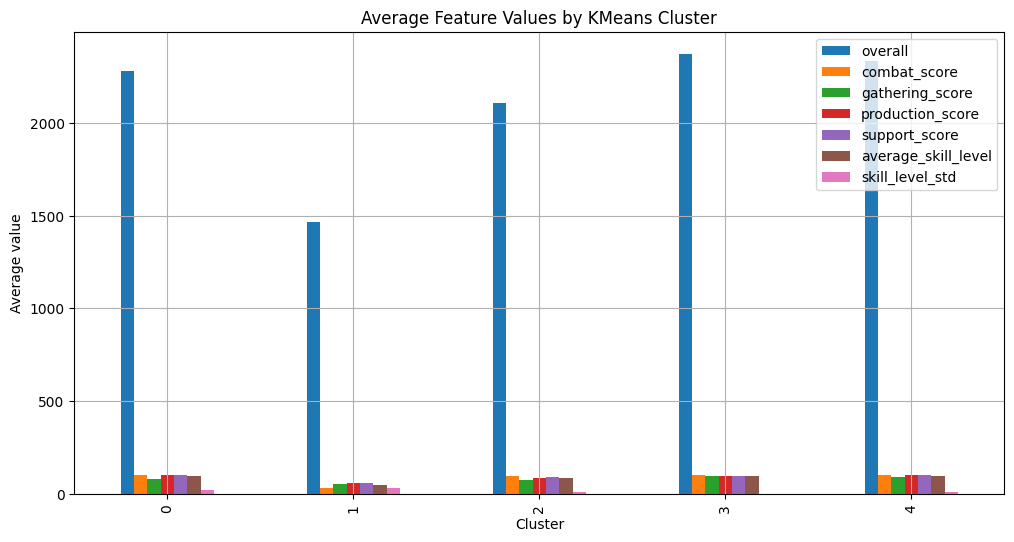

In [40]:
cluster_profile[profile_columns].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Feature Values by KMeans Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average value")
plt.grid(True)
plt.show()

In [41]:
for cluster_id in sorted(df_clustered["kmeans_cluster"].unique()):
    print(f"Cluster {cluster_id}")
    display(
        df_clustered[df_clustered["kmeans_cluster"] == cluster_id][
            ["player", "overall", "combat_score", "gathering_score", "production_score", "support_score", "average_skill_level"]
        ].head(10)
    )

Cluster 0


,player,overall,combat_score,gathering_score,production_score,support_score,average_skill_level
2,Lynx Titan,2278,99.0,79.4,99.0,99.0,94.916667
3,Hey Jase,2278,99.0,79.4,99.0,99.0,94.916667
6,Alkan,2278,99.0,79.4,99.0,99.0,94.916667


Cluster 1


,player,overall,combat_score,gathering_score,production_score,support_score,average_skill_level
0,Zezima,1466,33.0,52.8,56.25,59.75,49.333333


Cluster 2


,player,overall,combat_score,gathering_score,production_score,support_score,average_skill_level
1,eszcape,2107,96.571429,76.8,86.375,89.0,87.791667


Cluster 3


,player,overall,combat_score,gathering_score,production_score,support_score,average_skill_level
5,B0aty,2376,99.0,99.0,99.000,99.0,99.000000
8,A Cold One,2362,99.0,98.4,98.375,97.5,98.416667
9,SoloMission,2376,99.0,99.0,99.000,99.0,99.000000


Cluster 4


,player,overall,combat_score,gathering_score,production_score,support_score,average_skill_level
4,Woox,2340,99.0,91.8,99.0,99.0,97.50
7,Settled,2322,99.0,88.2,99.0,99.0,96.75


## 10. Compare with hierarchical clustering

A second clustering method is applied for comparison.

Hierarchical clustering groups players step-by-step instead of using centroids.

In [42]:
hierarchical = AgglomerativeClustering(n_clusters=selected_k)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

df_clustered["hierarchical_cluster"] = hierarchical_labels

df_clustered[["player", "kmeans_cluster", "hierarchical_cluster"]].head()

,player,kmeans_cluster,hierarchical_cluster
0,Zezima,1,3
1,eszcape,2,2
2,Lynx Titan,0,4
3,Hey Jase,0,4
4,Woox,4,1


In [43]:
df_clustered["hierarchical_cluster"].value_counts().sort_index()

hierarchical_cluster
0    3
1    2
2    1
3    1
4    3
Name: count, dtype: int64

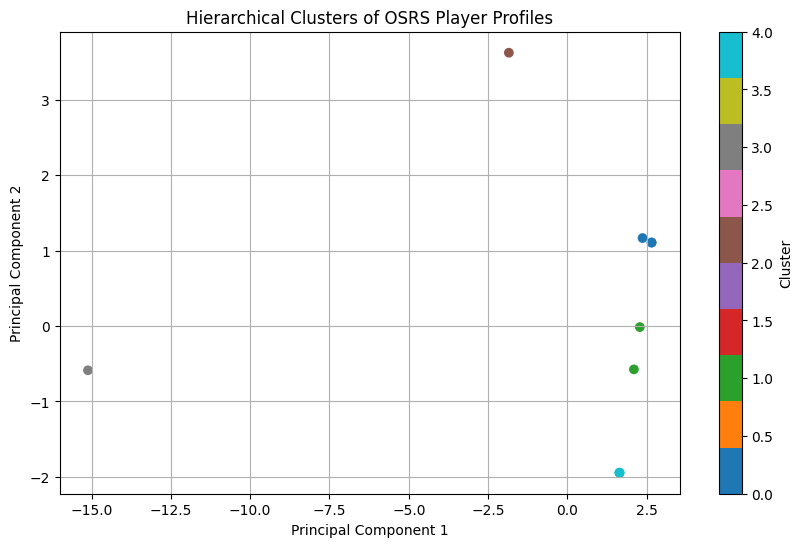

In [44]:
df_pca["hierarchical_cluster"] = hierarchical_labels

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_pca["pca_1"],
    df_pca["pca_2"],
    c=df_pca["hierarchical_cluster"],
    cmap="tab10"
)

plt.title("Hierarchical Clusters of OSRS Player Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")

plt.show()

## 11. Compare with DBSCAN

DBSCAN is a density-based clustering algorithm.

It can detect:

- irregular cluster shapes
- noise points
- outliers

In [45]:
dbscan = DBSCAN(
    eps=2.5,
    min_samples=3
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df_clustered["dbscan_cluster"] = dbscan_labels

In [46]:
df_clustered["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1    2
 0    8
Name: count, dtype: int64

## 12. Save clustering results

The final dataset with cluster labels is saved for later reporting and GitHub presentation.

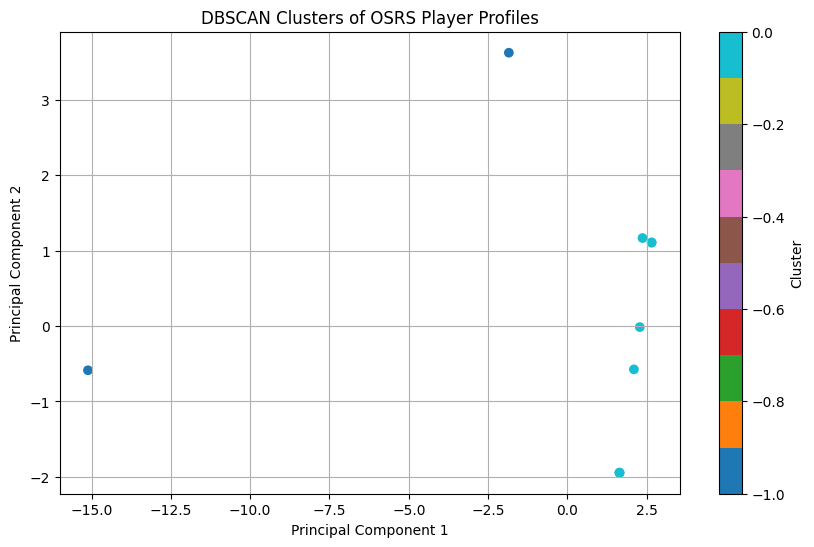

In [47]:
df_pca["dbscan_cluster"] = dbscan_labels

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_pca["pca_1"],
    df_pca["pca_2"],
    c=df_pca["dbscan_cluster"],
    cmap="tab10"
)

plt.title("DBSCAN Clusters of OSRS Player Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")

plt.show()

In [48]:
clustered_output_path = PROCESSED_DATA_DIR / "osrs_hiscores_clustered.csv"

df_clustered.to_csv(clustered_output_path, index=False, encoding="utf-8")

clustered_output_path

WindowsPath('C:/Projects/osrs-player-segmentation/data/processed/osrs_hiscores_clustered.csv')

## Summary

In this notebook, clustering methods were applied to OSRS player profiles.

The analysis included:

- feature matrix creation,
- standard scaling,
- PCA visualization,
- KMeans clustering,
- Elbow Method,
- Silhouette Score,
- cluster interpretation,
- hierarchical clustering,
- DBSCAN clustering,
- saving clustered results.

The KMeans model was used as the main clustering method because it provides interpretable centroid-based player groups.